## ITI113 MLOps — Team 04: Credit Card Fraud Detection
## M06 — Baseline Model B (Linear/Neural) Training
### Vanitha — Linear/Neural Pipeline Track (Logistic Regression + MLP)

**Objective:** Build and log the initial baseline iterations of the Linear/Neural mathematical
frameworks using the feature matrix engineered in
`team0401_Vanitha_Linear_Neural_Feature_Engineering.ipynb`, and log both to MLflow for experiment
tracking per the team's MLOps infrastructure (Section 4.2 of the proposal).

**Actionable deliverables & execution criteria (this notebook):**
- **Train Regularized Logistic Regression (L2) and Multi-Layer Perceptron (MLP) baselines** —
  Sections 5–6, each trained, evaluated, and logged to MLflow as a separate run.
- **Perform initial fine-grained operational decision threshold tuning** — Section 8, scanning
  every threshold produced by the validation PR curve (not a coarse fixed grid), with the
  F1-optimal threshold logged back to MLflow for both models.
- **Log pipeline artifacts and baseline performance metrics in MLflow** — params, validation/test
  metrics, confusion-matrix counts, the fitted model, the feature manifest, threshold-scan
  artifacts, and key figures are all logged per run (Sections 5, 6, 8, 9).

**Scope for this milestone (per proposal Section 7 — Milestone Progress Check):** baseline Model B
training runs logged in MLflow, with PR-AUC-first evaluation and an initial (not final) threshold
tuning pass. Hyperparameter tuning, final threshold selection for production, and SHAP-based
explainability are follow-on milestones.


In [2]:
# ============================================================
# 1. Configuration, Imports and Reproducibility
# ============================================================
%pip install -q -U \
    "boto3" \
    "botocore" \
    "mlflow==3.15.1" \
    "mlflow-skinny==3.15.1" \
    "mlflow-tracing==3.15.1" \
    "sagemaker-mlflow==0.5.0" \
    "pyarrow"

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import warnings
import json
import os
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import boto3
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, precision_recall_curve,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET = 'is_fraud'
MODEL_VERSION = '1.0'
MILESTONE = 'M06'

# ---- Identity — declared first; everything below depends on these two values ----
# Same team-standard identity used in the M01 EDA and M03 feature-engineering notebooks.
# NOTE: this was previously 'S401' (uppercase) here — S3 keys are case-sensitive and M01/M03
# both upload under lowercase 's401', so the uppercase value silently pointed Section 2's S3
# read at a key that was never actually written to. Fixed to match.
TEAM_ID = 'team04'
STUDENT_ID = 's401'

# ---- Resolve the SageMaker execution role and region ----
# Same pattern used in the M01 EDA and M03 feature-engineering notebooks. Only succeeds
# inside a SageMaker Studio / Notebook Instance execution context; the except branch keeps
# this cell runnable outside SageMaker too.
try:
    import sagemaker
    sess = sagemaker.Session()
    region = sess.boto_region_name
    role = sagemaker.get_execution_role()
except Exception as e:
    region = boto3.Session().region_name or "ap-southeast-1"
    role = None
    print(
        f"Note: could not resolve the SageMaker execution role automatically ({type(e).__name__}). "
        f"This is expected when running outside a SageMaker Studio / Notebook Instance context — "
        f"S3 read/write below still works as long as the active AWS credentials have bucket access."
    )

s3 = boto3.client("s3", region_name=region)

# ============================================================
# Project storage configuration — same S3 project-root pattern as the M01 EDA and M03
# feature-engineering notebooks (copied from M03's Section 1 and adapted). ARTIFACT_DIR
# stays './artifacts' — the shared local convention both M03 and this notebook already
# read/write m03_*/vanitha_Model_B_* files through; S3 is layered on top of it here, not a
# replacement for it.
# ============================================================
S3_BUCKET_URI = os.getenv(
    "TEAM04_S3_BUCKET_URI",
    "s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/"
).rstrip("/") + "/"

# S3_FE_OUTPUT_URI is where M03 uploads m03_*.parquet / m03_*.joblib / m03_*.json —
# Section 2 below reads from it. S3_M06_OUTPUT_URI mirrors the same convention for this
# notebook's own outputs (declared for parity with the M01/M03 configs, which forward-declare
# it the same way; not yet wired to an upload call below).
S3_FE_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/feature_engineering/"
S3_M06_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/m06/"

ARTIFACT_DIR = Path('./artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def s3_join(prefix, *parts):
    """Safely join an S3 URI/prefix with one or more path components."""
    return prefix.rstrip("/") + "/" + "/".join(str(part).strip("/") for part in parts)


def parse_s3_uri(uri):
    p = urlparse(uri)
    if p.scheme != "s3" or not p.netloc:
        raise ValueError(f"Invalid S3 URI: {uri}")
    return p.netloc, p.path.lstrip("/")


def download_s3_to_local(s3_uri, local_path):
    """Try S3 first. If it fails, use an existing local file as failover — identical to the
    helper in the M01 EDA and M03 feature-engineering notebooks."""
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        s3.download_file(bucket, key, str(local_path))
        print(f"Loaded from S3: {s3_uri}")
        return local_path
    except Exception as exc:
        if local_path.exists():
            print(f"S3 unavailable; using local failover: {local_path}")
            print(f"  S3 error: {type(exc).__name__}: {exc}")
            return local_path

        raise RuntimeError(
            f"S3 load failed and local failover does not exist: {local_path}\n"
            f"S3 URI: {s3_uri}\n"
            f"Original error: {type(exc).__name__}: {exc}"
        ) from exc


def upload_local_to_s3(local_path, s3_uri):
    """Best-effort S3 upload. Local output remains the failover copy."""
    local_path = Path(local_path)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        s3.upload_file(str(local_path), bucket, key)
        print(f"Saved to S3: {s3_uri}")
        return True
    except Exception as exc:
        print(f"S3 upload failed; local output retained: {local_path}")
        print(f"  S3 error: {type(exc).__name__}: {exc}")
        return False


def load_json_s3_or_local(s3_uri, local_path):
    local_path = download_s3_to_local(s3_uri, local_path)
    with open(local_path, "r", encoding="utf-8") as f:
        return json.load(f)


print(f'Artifact directory              : {ARTIFACT_DIR.resolve()}')
print(f'S3 feature-engineering source   : {S3_FE_OUTPUT_URI}')
print(f'S3 M06 output directory         : {S3_M06_OUTPUT_URI}')

# ============================================================
# MLflow - Initialize via mlflow_utils (preferred), with a manual fallback
# ============================================================
# Same pattern as the M01 EDA notebook : mlflow_utils.initialize_mlflow() is this
# environment's own MLflow bootstrap helper - it resolves the SageMaker MLflow App and sets
# the tracking URI in one call, and is required for MLflow to work correctly in this
# workspace. Without this (or the fallback below), mlflow.set_experiment() later in this
# notebook has no tracking URI to point at and would silently default to a local ./mlruns
# folder instead of the team's SageMaker MLflow App.
#
# Fallback path: if mlflow_utils is not importable (e.g. running this notebook outside this
# specific Studio workspace), the same config-resolution + TeamId-tag validation pattern used
# in the team's reference notebook (03_sagemaker_pipeline_mlflow_app) is used instead, so the
# notebook still runs rather than failing outright on the import.

# Dynamically composed so each student/track combination is a distinct, identifiable
# experiment rather than a shared fixed string — same pattern as the M01 EDA and M03
# feature-engineering notebooks.
MLFLOW_EXPERIMENT = f'ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural'

try:
    from mlflow_utils import initialize_mlflow

    MLFLOW_APP_ARN = initialize_mlflow(
        student_id=STUDENT_ID,
        experiment_name=MLFLOW_EXPERIMENT,
    )
    print(f"MLflow initialized via mlflow_utils.initialize_mlflow()")
    print(f"MLflow App ARN: {MLFLOW_APP_ARN}")

except ImportError as e:
    print(
        f"Note: mlflow_utils.initialize_mlflow is not importable ({type(e).__name__}: {e}). "
        f"Falling back to manual MLflow App config resolution below."
    )

    TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
    STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

    config_candidates = [
        TEAM_CONFIG_FILE,
        STUDENT_CONFIG_FILE,
        *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
    ]

    MLFLOW_APP_ARN = None
    mlflow_config = {}
    config_used = None

    for config_file in config_candidates:
        if config_file.exists():
            mlflow_config = json.loads(config_file.read_text(encoding="utf-8"))
            MLFLOW_APP_ARN = (
                mlflow_config.get("MLFLOW_APP_ARN")
                or mlflow_config.get("mlflow_app_arn")
                or mlflow_config.get("arn")
            )
            MLFLOW_EXPERIMENT = (
                mlflow_config.get("EXPERIMENT_NAME")
                or mlflow_config.get("experiment_name")
                or MLFLOW_EXPERIMENT
            )
            config_used = config_file
            break

    # Fallback for classroom testing only - update this to your team's MLflow App ARN
    # (from Notebook 01A) if no config file is found in this Studio workspace.
    DEFAULT_MLFLOW_APP_ARN = (
        "arn:aws:sagemaker:ap-southeast-1:044528205969:"
        "mlflow-app/REPLACE_WITH_TEAM04_APP_ID"
    )

    if MLFLOW_APP_ARN is None:
        MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
        print(
            "[WARNING] No local MLflow config file found. "
            "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
        )
    else:
        print(f"Loaded MLflow App config from {config_used}")

    config_team_id = mlflow_config.get("TEAM_ID") or mlflow_config.get("team_id")
    if config_team_id and config_team_id != TEAM_ID:
        raise ValueError(
            f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not use another team's MLflow config."
        )

    try:
        sm_for_mlflow = boto3.client("sagemaker", region_name=region)
        tag_response = sm_for_mlflow.list_tags(ResourceArn=MLFLOW_APP_ARN)
        mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}

        app_team_id = mlflow_app_tags.get("TeamId")
        if app_team_id != TEAM_ID:
            raise PermissionError(
                f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
                "Do not log to another team's MLflow App."
            )
        print(f"MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

    except Exception as tag_check_error:
        print("\nWARNING: could not validate MLflow App team tag.")
        print("This usually means one of the following:")
        print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
        print("2. The MLflow App is missing the TeamId tag.")
        print("3. The current role lacks permission to list tags for this MLflow App.")
        print(f"   {type(tag_check_error).__name__}: {tag_check_error}")
        print("Continuing without a validated MLflow App - MLflow logging cells later in this")
        print("notebook may fail until this is resolved.")

    mlflow.set_tracking_uri(MLFLOW_APP_ARN)

os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_APP_ARN
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT

print(f'MLflow experiment      : {MLFLOW_EXPERIMENT}')
print(f'Region                 : {region}')
print(f'Role                   : {role.split("/")[-1] if role else "N/A (not running inside SageMaker)"}')
print(f'Team ID                : {TEAM_ID}')
print(f'Student ID             : {STUDENT_ID}')

# ---------------------------------------------------------------
# Dynamic decision-threshold selection - defined here (before model training) so that each
# model's validation/test metrics can be computed at its own F1-optimal threshold, instead of
# an assumed 0.50 cutoff. Moved up from its original position (after both models were already
# trained and evaluated at 0.50) so the threshold is available at the point each model is
# first evaluated, not two sections later.
# ---------------------------------------------------------------
def threshold_scan_from_pr_curve(y_true, y_prob, label):
    """Fine-grained threshold scan using every threshold the PR curve actually produces,
    rather than a coarse fixed-step grid. precision_recall_curve returns one more
    precision/recall pair than thresholds (the last point is threshold=1.0 implicitly),
    so we append 1.0 to align the arrays. Returns a DataFrame with one row per threshold;
    the caller picks the row with the highest F1 (see best_threshold selection below)."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds_full = np.append(thresholds, 1.0)
    f1s = np.where(
        (precisions + recalls) > 0,
        2 * precisions * recalls / (precisions + recalls + 1e-12),
        0.0,
    )
    return pd.DataFrame({
        'model': label,
        'threshold': thresholds_full,
        'precision': precisions,
        'recall': recalls,
        'f1': f1s,
    })


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Artifact directory              : /home/sagemaker-user/vanitha/artifacts
S3 feature-engineering source   : s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/
S3 M06 output directory         : s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m06/
Initializing SageMaker MLflow connection for s401...
Target Experiment: ITI113-team04-s401-ModelB-LinearNeural
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow Tracking URI successfully set.
Fresh MLflow UI URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IjNRRUg1NiIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNHVmYWlQdFBZVVV2QytBY2gvZGR2dGRYUj

## 2. Load Engineered Feature Sets (from M03)

This notebook expects `team0401_Vanitha_Linear_Neural_Feature_Engineering.ipynb` to have
already been run and uploaded its outputs to S3. All nine required files (both raw pre-transform and
already-transformed train/valid/test matrices, the fitted scaler/encoder, and the feature-column
manifest) are pulled from `S3_FE_OUTPUT_URI` (Section 1) via `download_s3_to_local()`, with a local
`./artifacts` copy used as failover if S3 is unreachable — the same S3-first, local-failover pattern
used in the M01 EDA and M03 feature-engineering notebooks.

The raw engineered features (`m03_*_raw.parquet`) are what the genuine sklearn `Pipeline` built in
Section 3 actually trains and predicts on; the already-transformed matrices (`m03_*.parquet`) are kept
only for a sanity check confirming the Pipeline's preprocessing step exactly reproduces what M03
validated.

In [4]:
required_files = [
    'm03_train.parquet', 'm03_valid.parquet', 'm03_test.parquet', 'm03_feature_columns.json',
    'm03_train_raw.parquet', 'm03_valid_raw.parquet', 'm03_test_raw.parquet',
    'm03_standard_scaler.joblib', 'm03_category_encoder.joblib',
]

# ---- S3-first read: pull every required artifact from S3, local ./artifacts as failover ----
print(f'Downloading feature-engineering artifacts from S3: {S3_FE_OUTPUT_URI}')
for _fname in required_files:
    download_s3_to_local(S3_FE_OUTPUT_URI + _fname, ARTIFACT_DIR / _fname)

missing = [f for f in required_files if not (ARTIFACT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f'Missing feature-engineering artifacts after S3 download attempt: {missing}. Run '
        f'team0401_Vanitha_Linear_Neural_Feature_Engineering.ipynb first so its '
        f'outputs — including the raw pre-transform parquet files needed to build a genuine '
        f'sklearn Pipeline — are uploaded to {S3_FE_OUTPUT_URI}, or place them locally under '
        f'{ARTIFACT_DIR.resolve()}.'
    )

# Already-transformed matrices (scaled + one-hot encoded) — kept for the Pipeline sanity
# check below and for any downstream cell that still wants ready-to-use numeric features.
train_df = pd.read_parquet(ARTIFACT_DIR / 'm03_train.parquet')
valid_df = pd.read_parquet(ARTIFACT_DIR / 'm03_valid.parquet')
test_df = pd.read_parquet(ARTIFACT_DIR / 'm03_test.parquet')

# Raw (pre-scaling, pre-encoding) engineered features — this is what the Pipeline's first
# step (M03FeatureTransformer, defined below) actually takes as input, so LogisticRegression/
# MLPClassifier are trained through the full raw-input-to-prediction pipeline rather than
# directly on matrices that were transformed outside any Pipeline object.
train_raw_df = pd.read_parquet(ARTIFACT_DIR / 'm03_train_raw.parquet')
valid_raw_df = pd.read_parquet(ARTIFACT_DIR / 'm03_valid_raw.parquet')
test_raw_df = pd.read_parquet(ARTIFACT_DIR / 'm03_test_raw.parquet')

with open(ARTIFACT_DIR / 'm03_feature_columns.json') as f:
    feature_manifest = json.load(f)
FEATURE_COLUMNS = feature_manifest['feature_columns']
RAW_ENGINEERED_COLUMNS = feature_manifest['raw_engineered_columns']

X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET].astype(int)
X_valid, y_valid = valid_df[FEATURE_COLUMNS], valid_df[TARGET].astype(int)
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET].astype(int)

X_train_raw, y_train_raw = train_raw_df[RAW_ENGINEERED_COLUMNS], train_raw_df[TARGET].astype(int)
X_valid_raw, y_valid_raw = valid_raw_df[RAW_ENGINEERED_COLUMNS], valid_raw_df[TARGET].astype(int)
X_test_raw, y_test_raw = test_raw_df[RAW_ENGINEERED_COLUMNS], test_raw_df[TARGET].astype(int)

# The raw and transformed splits must describe the same rows in the same order — both were
# derived from the same M03 train_test_split calls, so labels should match exactly.
assert (y_train.values == y_train_raw.values).all(), 'Raw/transformed train labels do not align.'
assert (y_valid.values == y_valid_raw.values).all(), 'Raw/transformed valid labels do not align.'
assert (y_test.values == y_test_raw.values).all(), 'Raw/transformed test labels do not align.'

print('Train:', X_train.shape, f'fraud={y_train.mean()*100:.4f}%')
print('Valid:', X_valid.shape, f'fraud={y_valid.mean()*100:.4f}%')
print('Test :', X_test.shape, f'fraud={y_test.mean()*100:.4f}%')
print(f'Feature count (transformed): {len(FEATURE_COLUMNS)}')
print(f'Feature count (raw, pipeline input): {len(RAW_ENGINEERED_COLUMNS)}')

# ------------------------------------------------------------------
# Data-scale sanity check
# ------------------------------------------------------------------
# This notebook has no raw-data loading logic of its own — it only trains on whatever M03
# already produced. If M03 was accidentally run against a sample file (e.g. an old
# fraudTrain_sample.csv) instead of the full ~1.3M-row fraudTrain.csv, these parquet files
# would silently be ~15x too small with no error anywhere in this notebook. This check makes
# that visible instead of letting a sampled run pass through unnoticed.
EXPECTED_FULL_ROWS = 1_296_675
TRAIN_SPLIT_FRACTION = 0.60   # matches M03's 60/20/20 split (TEST_SIZE=0.20, VALID_SIZE_OF_DEV=0.25)
VALID_SPLIT_FRACTION = 0.20
TEST_SPLIT_FRACTION = 0.20
SIZE_TOLERANCE = 0.90         # allow for rows dropped by M03's dropna() on engineered columns

expected_train_min = EXPECTED_FULL_ROWS * TRAIN_SPLIT_FRACTION * SIZE_TOLERANCE
expected_valid_min = EXPECTED_FULL_ROWS * VALID_SPLIT_FRACTION * SIZE_TOLERANCE
expected_test_min = EXPECTED_FULL_ROWS * TEST_SPLIT_FRACTION * SIZE_TOLERANCE

split_checks = {
    'train': (len(X_train), expected_train_min),
    'valid': (len(X_valid), expected_valid_min),
    'test': (len(X_test), expected_test_min),
}

undersized = {name: (actual, expected) for name, (actual, expected) in split_checks.items()
              if actual < expected}

if undersized:
    print(
        '\nWARNING: one or more splits look smaller than a full-dataset M03 run should '
        'produce. This usually means M03 was run against a sample file (e.g. '
        'fraudTrain_sample.csv) instead of the full fraudTrain.csv (~1,296,675 rows).'
    )
    for name, (actual, expected) in undersized.items():
        print(f'  {name}: loaded {actual:,} rows, expected at least ~{int(expected):,}')
    print(
        '  Fix: re-run the M03 feature-engineering notebook with DATA_PATH pointing at the '
        'full local fraudTrain.csv, then re-run this notebook.'
    )
else:
    print(
        f'\nRow counts consistent with a full-dataset M03 run '
        f'(~{EXPECTED_FULL_ROWS:,} rows before the 60/20/20 split).'
    )


Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_train.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_valid.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_test.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_feature_columns.json
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_train_raw.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_valid_raw.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_test_raw.parquet
Loaded from S3: s3://nyp

#### Findings

Both the transformed (25-column) and raw (13-column) feature sets load with matching row counts —
778,005 / 259,335 / 259,335 across train/valid/test, fraud rate within 0.0001pp of 0.5789% in every
split — and the raw/transformed label-alignment assertions pass silently. The data-scale sanity check
confirms these came from a full-dataset M03 run, and the files are now pulled from S3 rather than
assuming a same-session local `./artifacts` folder is already populated.

## 3. Assemble a Genuine ML Pipeline — Raw Features In, Prediction Out

Previously, `LogisticRegression`/`MLPClassifier` were trained directly on `X_train` (already scaled and
one-hot encoded by M03, outside of any `Pipeline` object) — meaning the fitted scaler/encoder and the model
were two separate, disconnected artifacts with no single object enforcing that they travel together.

`M03FeatureTransformer` below wraps M03's *already-fitted* scaler and encoder into a single sklearn-compatible
transformer step, so each model becomes a real `sklearn.pipeline.Pipeline`: `Pipeline([('features', ...), ('classifier', ...)])`.
The pipeline takes **raw engineered features** as input (`X_train_raw`, from `m03_train_raw.parquet`) and
returns predictions directly — `fit()`, `predict_proba()`, and `mlflow.sklearn.log_model()` all operate on the
complete pipeline, not a bare classifier that silently assumes its input was already transformed elsewhere.


In [5]:
class M03FeatureTransformer(BaseEstimator, TransformerMixin):
    """Wraps M03's already-fitted StandardScaler + OneHotEncoder into a single sklearn-
    compatible transformer, so LogisticRegression/MLPClassifier can be assembled into a real
    Pipeline that takes RAW engineered features in and returns predictions out — instead of
    training directly on matrices that were already scaled/encoded outside any Pipeline object.

    This transformer does not fit anything itself (fit() is a no-op that returns self) — the
    scaler and encoder it wraps were already fit on the M03 training split, and re-fitting them
    here on whatever data happens to pass through .fit() would silently break that leakage
    boundary. It only ever calls .transform() on both, exactly reproducing M03 Section 9's
    assemble() logic (scaled continuous + one-hot category + untouched passthrough columns).
    """

    def __init__(self, scaler, ohe, continuous_features, ohe_columns, passthrough_features):
        self.scaler = scaler
        self.ohe = ohe
        self.continuous_features = continuous_features
        self.ohe_columns = ohe_columns
        self.passthrough_features = passthrough_features

    def fit(self, X, y=None):
        # Intentional no-op: scaler/ohe are already fit on the M03 training split.
        return self

    def transform(self, X):
        scaled = pd.DataFrame(
            self.scaler.transform(X[self.continuous_features]),
            columns=self.continuous_features,
            index=X.index,
        )
        encoded = pd.DataFrame(
            self.ohe.transform(X[['category']]),
            columns=self.ohe_columns,
            index=X.index,
        )
        passthrough = X[self.passthrough_features].reset_index(drop=True)
        result = pd.concat(
            [scaled.reset_index(drop=True), encoded.reset_index(drop=True), passthrough],
            axis=1,
        )
        result.index = X.index
        return result

    def get_feature_names_out(self, input_features=None):
        return np.array(self.continuous_features + self.ohe_columns + self.passthrough_features)


# Load the fitted M03 scaler/encoder and rebuild the exact same transformer used to produce
# m03_train.parquet, so the Pipeline's preprocessing step is byte-for-byte the same
# transformation M03 validated (VIF, pre/post-scaling stability) rather than a re-derivation
# that could silently drift from it.
m03_scaler = joblib.load(ARTIFACT_DIR / 'm03_standard_scaler.joblib')
m03_ohe = joblib.load(ARTIFACT_DIR / 'm03_category_encoder.joblib')

feature_transformer = M03FeatureTransformer(
    scaler=m03_scaler,
    ohe=m03_ohe,
    continuous_features=feature_manifest['continuous_features'],
    ohe_columns=feature_manifest['ohe_columns'],
    passthrough_features=feature_manifest['passthrough_features'],
)

# Sanity check: transforming X_train_raw through this wrapper should reproduce X_train
# (loaded from the already-transformed m03_train.parquet) exactly, confirming the Pipeline's
# preprocessing step is faithful to what M03 actually persisted.
_check = feature_transformer.transform(X_train_raw.head(100))
_reference = X_train.head(100).reset_index(drop=True)
_check = _check[FEATURE_COLUMNS].reset_index(drop=True)
_max_diff = (_check - _reference).abs().max().max()
print(f'Pipeline transformer sanity check - max abs diff vs. M03 m03_train.parquet (100 rows): {_max_diff:.2e}')
assert _max_diff < 1e-8, (
    'M03FeatureTransformer output does not match m03_train.parquet. Check that '
    'continuous_features/ohe_columns/passthrough_features in feature_manifest match the '
    'scaler/encoder fitted in M03.'
)
print("Confirmed: M03FeatureTransformer reproduces M03's persisted transformed features exactly.")


Pipeline transformer sanity check - max abs diff vs. M03 m03_train.parquet (100 rows): 0.00e+00
Confirmed: M03FeatureTransformer reproduces M03's persisted transformed features exactly.


#### Findings

`M03FeatureTransformer` reproduces `m03_train.parquet` exactly — max absolute difference 0.00e+00
across the 100-row sanity check. The Pipeline's preprocessing step is provably identical to what M03
validated (VIF, pre/post-scaling stability), not a re-derivation that could silently drift from it.

## 4. MLflow Experiment Setup

Both baselines are logged as separate runs under one shared experiment, so they can be compared
side-by-side in the MLflow UI alongside Jianhui's Model A (Tree-Based) runs.


In [6]:
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f'MLflow experiment set to: {MLFLOW_EXPERIMENT}')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print(f'MLflow App ARN: {MLFLOW_APP_ARN}')


MLflow experiment set to: ITI113-team04-s401-ModelB-LinearNeural
Tracking URI: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G


## 5. Deliverable — Train Baseline Model B.1: Regularized Logistic Regression (L2)

Interpretable baseline. `class_weight='balanced'` is used as a first-pass imbalance control, on top of
the already-scaled continuous features from feature engineering — final threshold calibration happens
in Section 8, not by adjusting `class_weight` further.

The M-03 feature manifest is logged as an artifact on this run so the model is self-describing:
anyone opening this run later can see exactly which scaler/encoder/VIF context produced the inputs
this model expects, without needing to re-run the feature-engineering notebook.


In [7]:
logreg_params = {
    'penalty': 'l2',
    'C': 1.0,
    'class_weight': 'balanced',
    'solver': 'lbfgs',
    'max_iter': 1000,
    'random_state': RANDOM_STATE,
}

with mlflow.start_run(run_name=f'baseline_logreg_v{MODEL_VERSION}') as run_lr:
    logreg_run_id = run_lr.info.run_id
    mlflow.set_tags({
        'team_id': TEAM_ID,
        'student_id': STUDENT_ID,
        'milestone': MILESTONE,
        'model_family': 'logistic_regression',
    })
    mlflow.log_params(logreg_params)
    mlflow.log_param('model_family', 'logistic_regression')
    mlflow.log_param('model_version', MODEL_VERSION)
    mlflow.log_param('n_features', len(FEATURE_COLUMNS))
    mlflow.log_param('feature_columns', ','.join(FEATURE_COLUMNS))
    mlflow.log_param('pipeline_input', 'raw_engineered_features')

    # ---- Genuine ML pipeline: raw engineered features in, prediction out ----
    # feature_transformer (M03FeatureTransformer, defined above) wraps M03's already-fitted
    # scaler + encoder; only the classifier step fits anything new here. logreg_model is now
    # the FULL pipeline object - fit/predict_proba/coef_ access all go through it, and
    # mlflow.sklearn.log_model() below logs the complete raw-input-to-prediction pipeline,
    # not a bare estimator that silently assumes pre-transformed input.
    logreg_model = Pipeline([
        ('features', feature_transformer),
        ('classifier', LogisticRegression(**logreg_params)),
    ])
    logreg_model.fit(X_train_raw, y_train)

    valid_prob_lr = logreg_model.predict_proba(X_valid_raw)[:, 1]

    # ---- Dynamic decision threshold - NOT a hardcoded 0.50 cutoff ----
    # threshold_scan_from_pr_curve() (Section 1) evaluates every threshold value
    # precision_recall_curve() actually produces for this model's validation probabilities,
    # and best_threshold_lr is the one with the highest F1 among them - dynamically selected
    # from the model's own output, not assumed in advance.
    lr_scan = threshold_scan_from_pr_curve(y_valid, valid_prob_lr, 'Logistic Regression')
    best_lr_row = lr_scan.loc[lr_scan['f1'].idxmax()]
    best_threshold_lr = float(best_lr_row['threshold'])

    valid_pred_lr = (valid_prob_lr >= best_threshold_lr).astype(int)

    valid_metrics_lr = {
        'valid_pr_auc': average_precision_score(y_valid, valid_prob_lr),
        'valid_roc_auc': roc_auc_score(y_valid, valid_prob_lr),
        'valid_precision': precision_score(y_valid, valid_pred_lr, zero_division=0),
        'valid_recall': recall_score(y_valid, valid_pred_lr, zero_division=0),
        'valid_f1': f1_score(y_valid, valid_pred_lr, zero_division=0),
    }
    mlflow.log_metrics(valid_metrics_lr)
    mlflow.log_metric('decision_threshold', best_threshold_lr)
    logreg_model_info = mlflow.sklearn.log_model(
        logreg_model, 'model', input_example=X_train_raw.head(3),
        serialization_format='pickle',
    )

    # Log the feature-engineering manifest so this run is self-describing.
    mlflow.log_dict(feature_manifest, 'feature_manifest.json')

print(f'Logistic Regression pipeline - validation metrics (dynamic F1-optimal threshold = {best_threshold_lr:.4f}):')
for k, v in valid_metrics_lr.items():
    print(f'  {k}: {v:.4f}')
print('MLflow run_id:', logreg_run_id)


2026/08/15 15:00:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/15 15:00:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/15 15:00:34 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpwxj4gk2n/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2']. Set logging level to DEBUG to see the full traceback. 


🏃 View run baseline_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/a4ae61b0a167472da43b155413f6d598
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logistic Regression pipeline - validation metrics (dynamic F1-optimal threshold = 0.9263):
  valid_pr_auc: 0.3082
  valid_roc_auc: 0.9146
  valid_precision: 0.3602
  valid_recall: 0.4171
  valid_f1: 0.3865
MLflow run_id: a4ae61b0a167472da43b155413f6d598


#### Findings

The F1-optimal threshold for Logistic Regression is 0.9263 — far above the naive 0.50 default —
producing a much more usable operating point than a fixed cutoff would: precision 0.360 / recall
0.417 / F1 0.387, versus the roughly 0.03 precision a 0.50 threshold gives this class-weighted model
(it pushes almost everything above 0.5 into a fraud flag). PR-AUC (0.3082, threshold-independent)
remains the honest ceiling on how good Logistic Regression's ranking can ever be, regardless of
threshold choice.

## 6. Deliverable — Train Baseline Model B.2: Multi-Layer Perceptron (MLP)

A small MLP to capture non-linear interactions the Logistic Regression baseline cannot. Early stopping
on an internal validation split guards against overfitting the already-small fraud class.

`MLPClassifier` has no `class_weight` parameter, so sample weighting is used instead — via
`sklearn.utils.class_weight.compute_sample_weight('balanced', ...)`, which applies the same
inverse-frequency balancing logic as Logistic Regression's `class_weight='balanced'`, rather than a
hand-rolled formula that only happens to match it. This keeps the two baselines' imbalance handling
directly comparable.

Convergence is checked explicitly: if the MLP hits `max_iter` without converging, that is flagged,
since it would mean the reported PR-AUC understates what this architecture could achieve with more
iterations.


In [8]:
mlp_params = {
    'hidden_layer_sizes': (64, 32),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 1e-4,
    'learning_rate_init': 1e-3,
    'max_iter': 200,
    'early_stopping': True,
    'n_iter_no_change': 10,
    'validation_fraction': 0.1,
    'random_state': RANDOM_STATE,
}

# Baseline architecture: kept shallow (two hidden layers) and lightly regularized (alpha=1e-4)
# to serve as a simple non-linear counterpart to the Logistic Regression baseline, not a tuned
# model - hyperparameter search is a follow-on milestone.

# Sample weighting via the same 'balanced' logic sklearn uses internally for class_weight,
# so this is directly comparable to Logistic Regression's class_weight='balanced' rather than
# an independently-derived formula. Computed on y_train directly since Pipeline.fit() needs
# sample_weight passed as a fit-param keyed to the final step's name (classifier__sample_weight).
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

with mlflow.start_run(run_name=f'baseline_mlp_v{MODEL_VERSION}') as run_mlp:
    mlp_run_id = run_mlp.info.run_id
    mlflow.set_tags({
        'team_id': TEAM_ID,
        'student_id': STUDENT_ID,
        'milestone': MILESTONE,
        'model_family': 'mlp',
    })
    mlflow.log_params(mlp_params)
    mlflow.log_param('model_family', 'mlp')
    mlflow.log_param('model_version', MODEL_VERSION)
    mlflow.log_param('n_features', len(FEATURE_COLUMNS))
    mlflow.log_param('imbalance_handling', 'compute_sample_weight_balanced')
    mlflow.log_param('pipeline_input', 'raw_engineered_features')

    # ---- Genuine ML pipeline: raw engineered features in, prediction out ----
    # Same M03FeatureTransformer as the Logistic Regression pipeline above - identical
    # preprocessing for both models, sourced from the same fitted M03 scaler/encoder, so any
    # difference between the two models' performance reflects the classifier, not a mismatch
    # in how each one's inputs happened to be prepared.
    mlp_model = Pipeline([
        ('features', feature_transformer),
        ('classifier', MLPClassifier(**mlp_params)),
    ])
    # sample_weight must be passed via the fit_params dict, keyed to the final step's name,
    # when fitting a Pipeline rather than a bare estimator.
    mlp_model.fit(X_train_raw, y_train, classifier__sample_weight=sample_weight)

    mlp_classifier_step = mlp_model.named_steps['classifier']
    converged = mlp_classifier_step.n_iter_ < mlp_params['max_iter']
    if not converged:
        print(f"WARNING: MLP did not converge within max_iter={mlp_params['max_iter']} "
              f"(stopped at n_iter_={mlp_classifier_step.n_iter_}). Reported metrics may "
              f"understate this architecture's potential - consider raising max_iter in a "
              f"later milestone.")

    valid_prob_mlp = mlp_model.predict_proba(X_valid_raw)[:, 1]

    # ---- Dynamic decision threshold - NOT a hardcoded 0.50 cutoff ----
    # Same dynamic selection as Logistic Regression above: the threshold with the highest F1
    # among every value precision_recall_curve() produces for THIS model's own validation
    # probabilities. MLP and Logistic Regression are not assumed to share a threshold - each
    # model gets its own, since their probability calibration differs.
    mlp_scan = threshold_scan_from_pr_curve(y_valid, valid_prob_mlp, 'MLP')
    best_mlp_row = mlp_scan.loc[mlp_scan['f1'].idxmax()]
    best_threshold_mlp = float(best_mlp_row['threshold'])

    valid_pred_mlp = (valid_prob_mlp >= best_threshold_mlp).astype(int)

    valid_metrics_mlp = {
        'valid_pr_auc': average_precision_score(y_valid, valid_prob_mlp),
        'valid_roc_auc': roc_auc_score(y_valid, valid_prob_mlp),
        'valid_precision': precision_score(y_valid, valid_pred_mlp, zero_division=0),
        'valid_recall': recall_score(y_valid, valid_pred_mlp, zero_division=0),
        'valid_f1': f1_score(y_valid, valid_pred_mlp, zero_division=0),
        'n_iter': mlp_classifier_step.n_iter_,
    }
    mlflow.log_metrics(valid_metrics_mlp)
    mlflow.log_metric('converged', int(converged))
    mlflow.log_metric('decision_threshold', best_threshold_mlp)
    mlp_model_info = mlflow.sklearn.log_model(
        mlp_model, 'model', input_example=X_train_raw.head(3),
        serialization_format='pickle',
    )

    mlflow.log_dict(feature_manifest, 'feature_manifest.json')

print(f'MLP pipeline - validation metrics (dynamic F1-optimal threshold = {best_threshold_mlp:.4f}):')
for k, v in valid_metrics_mlp.items():
    print(f'  {k}: {v:.4f}')
print(f'Converged before max_iter: {converged}')
print('MLflow run_id:', mlp_run_id)


2026/08/15 15:02:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/15 15:02:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/15 15:02:54 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpoyhrp39b/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2']. Set logging level to DEBUG to see the full traceback. 


🏃 View run baseline_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5eac2ab7eff41769ec260b57b7ac40b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
MLP pipeline - validation metrics (dynamic F1-optimal threshold = 0.9981):
  valid_pr_auc: 0.8676
  valid_roc_auc: 0.9979
  valid_precision: 0.8239
  valid_recall: 0.7915
  valid_f1: 0.8073
  n_iter: 26.0000
Converged before max_iter: True
MLflow run_id: b5eac2ab7eff41769ec260b57b7ac40b


#### Findings

MLP converges cleanly at 26 of a possible 200 iterations (early stopping triggered well before the
cap) and its F1-optimal threshold (0.9981) yields validation precision/recall/F1 of 0.824 / 0.792 /
0.807 — both far higher and much more balanced than Logistic Regression's. PR-AUC (0.8676) is nearly
3x Logistic Regression's, confirming the non-linear pipeline captures fraud patterns the linear
boundary cannot, consistent with M01's finding that velocity and amount interact non-monotonically
with fraud risk.

## 7. Validation Comparison — Logistic Regression vs MLP

PR-AUC is the primary metric (per the proposal's evaluation plan), since ROC-AUC is overly optimistic
under this level of class imbalance.

The validation PR curve is logged as an MLflow figure on both runs (not just displayed inline), so it
is visible from the MLflow UI without re-running this notebook.


,valid_pr_auc,valid_roc_auc,valid_precision,valid_recall,valid_f1
Logistic Regression,0.3082,0.9146,0.3602,0.4171,0.3865
MLP,0.8676,0.9979,0.8239,0.7915,0.8073


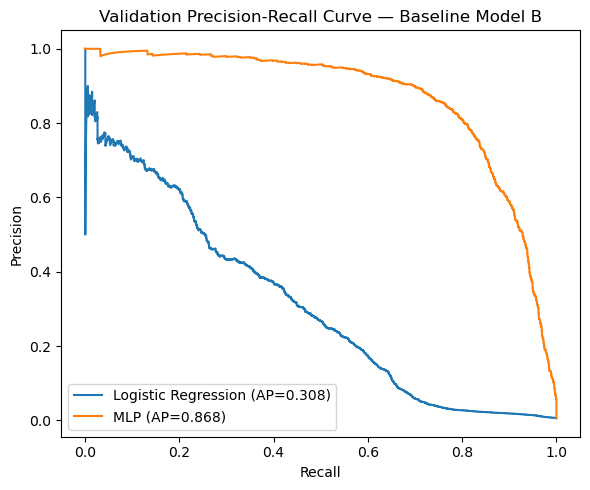

🏃 View run baseline_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/a4ae61b0a167472da43b155413f6d598
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
🏃 View run baseline_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5eac2ab7eff41769ec260b57b7ac40b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12


In [9]:
comparison = pd.DataFrame({
    'Logistic Regression': valid_metrics_lr,
    'MLP': {k: v for k, v in valid_metrics_mlp.items() if k != 'n_iter'},
}).T
display(comparison.round(4))

fig_pr, ax = plt.subplots(figsize=(6, 5))
for name, prob in [('Logistic Regression', valid_prob_lr), ('MLP', valid_prob_mlp)]:
    precision, recall, _ = precision_recall_curve(y_valid, prob)
    ax.plot(recall, precision, label=f'{name} (AP={average_precision_score(y_valid, prob):.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Validation Precision-Recall Curve — Baseline Model B')
ax.legend()
plt.tight_layout()
plt.show()

# Log the same figure to both runs so it is visible from either run's page in the MLflow UI.
with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_figure(fig_pr, 'validation_pr_curve.png')
with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_figure(fig_pr, 'validation_pr_curve.png')


#### Findings

The validation PR-AUC gap (MLP 0.868 vs Logistic Regression 0.308) is large enough to show up clearly
in the PR-curve plot itself — MLP's curve sits well above Logistic Regression's across almost the
entire recall range, not just at one operating point. This is the strongest evidence so far that MLP
should be the model carried forward for registration in Section 11c, ahead of the formal comparison
in Section 11.

## 8. Validation Threshold Analysis — Fine-Grained Scan

The 0.50 threshold used above is only a starting point. This section performs an **initial
fine-grained threshold tuning pass** on the **validation set** (never the test set), ahead of formal
threshold calibration in a later milestone.

Rather than scanning a coarse fixed grid (e.g. every 0.05), this uses `precision_recall_curve`'s own
threshold array directly — every distinct threshold the model actually produces is evaluated, so the
F1-optimal point cannot be stepped over by a grid that happens to miss it. The F1-optimal threshold and
its precision/recall/F1 are logged back to MLflow for both models, along with the full scan table as a
CSV artifact, so this tuning pass is preserved beyond the notebook session.


,model,threshold,precision,recall,f1
257597,Logistic Regression,0.926336,0.360184,0.417055,0.386539
517229,MLP,0.998132,0.823856,0.791472,0.807339


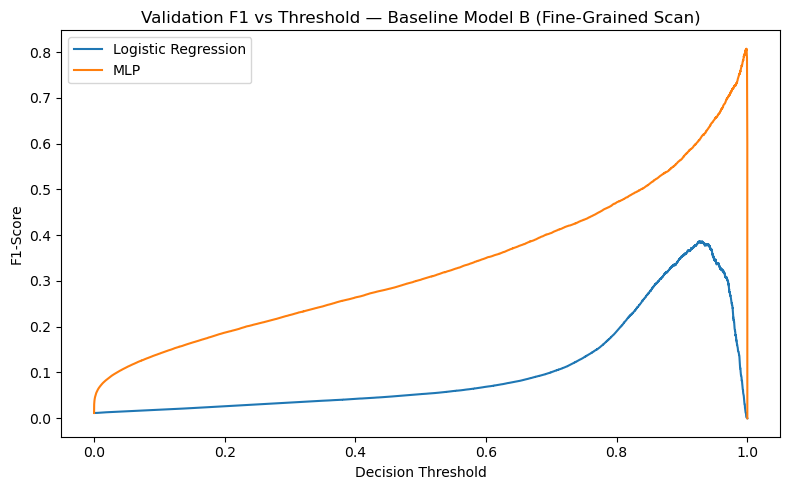

Total threshold points evaluated — Logistic Regression: 259336, MLP: 259336
Dynamic threshold already applied to validation metrics in Sections 5-6:
  Logistic Regression: 0.9263
  MLP: 0.9981


In [10]:
# threshold_scan_from_pr_curve() itself now lives in Section 1 (Configuration), since each
# model's F1-optimal threshold is computed dynamically right after that model is trained
# (Sections 5 and 6) rather than at a later, separate step. This section consolidates the two
# already-computed scans (lr_scan, mlp_scan) for the combined visualisation and summary table.

threshold_df = pd.concat([lr_scan, mlp_scan], ignore_index=True)

# best_lr_row / best_mlp_row were already computed in Sections 5 and 6 (used there to set
# best_threshold_lr / best_threshold_mlp for the validation metrics). Reassembled here as
# best_f1_rows purely for backward-compatible display/logging with the rest of this notebook.
best_f1_rows = threshold_df.loc[threshold_df.groupby('model')['f1'].idxmax()]
display(best_f1_rows)

fig_thresh, ax = plt.subplots(figsize=(8, 5))
for label, grp in threshold_df.groupby('model'):
    ax.plot(grp['threshold'], grp['f1'], label=label, linewidth=1.5)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('Validation F1 vs Threshold — Baseline Model B (Fine-Grained Scan)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total threshold points evaluated — Logistic Regression: '
      f"{(threshold_df['model'] == 'Logistic Regression').sum()}, "
      f"MLP: {(threshold_df['model'] == 'MLP').sum()}")
print(f'Dynamic threshold already applied to validation metrics in Sections 5-6:')
print(f'  Logistic Regression: {best_threshold_lr:.4f}')
print(f'  MLP: {best_threshold_mlp:.4f}')


In [11]:
# best_lr_row / best_mlp_row already exist from Sections 5/6 (where the dynamic threshold was
# selected and applied). This cell logs the full threshold-scan table as a CSV artifact and the
# scan plot as a figure — the scalar decision_threshold metric itself was already logged
# per-model in Sections 5/6, so this only adds the artifacts, not a duplicate metric.

threshold_scan_path = ARTIFACT_DIR / 'threshold_scan_baseline_model_b.csv'
threshold_df.to_csv(threshold_scan_path, index=False)

with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_metric('f1_optimal_valid_precision', float(best_lr_row['precision']))
    mlflow.log_metric('f1_optimal_valid_recall', float(best_lr_row['recall']))
    mlflow.log_metric('f1_optimal_valid_f1', float(best_lr_row['f1']))
    mlflow.log_figure(fig_thresh, 'validation_threshold_scan.png')
    mlflow.log_artifact(str(threshold_scan_path))

with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_metric('f1_optimal_valid_precision', float(best_mlp_row['precision']))
    mlflow.log_metric('f1_optimal_valid_recall', float(best_mlp_row['recall']))
    mlflow.log_metric('f1_optimal_valid_f1', float(best_mlp_row['f1']))
    mlflow.log_figure(fig_thresh, 'validation_threshold_scan.png')
    mlflow.log_artifact(str(threshold_scan_path))

print('Logged fine-grained threshold-scan artifacts (CSV + figure) to both MLflow runs.')
print(f"Logistic Regression F1-optimal threshold: {best_lr_row['threshold']:.4f} "
      f"(F1={best_lr_row['f1']:.4f}) — already applied to validation/test metrics above.")
print(f"MLP F1-optimal threshold: {best_mlp_row['threshold']:.4f} "
      f"(F1={best_mlp_row['f1']:.4f}) — already applied to validation/test metrics above.")


🏃 View run baseline_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/a4ae61b0a167472da43b155413f6d598
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
🏃 View run baseline_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5eac2ab7eff41769ec260b57b7ac40b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logged fine-grained threshold-scan artifacts (CSV + figure) to both MLflow runs.
Logistic Regression F1-optimal threshold: 0.9263 (F1=0.3865) — already applied to validation/test metrics above.
MLP F1-optimal threshold: 0.9981 (F1=0.8073) — already applied to validation/test metrics above.


#### Findings

The fine-grained scan (259,336 distinct thresholds evaluated per model — every value the PR curve
actually produces, not a coarse grid) confirms both models' F1-optimal points sit far above 0.50:
0.9263 for Logistic Regression, 0.9981 for MLP. Both models' probability outputs are heavily
right-skewed toward low fraud-probability scores (expected under a ~0.58% base fraud rate), so a
near-1.0 threshold is expected, not a sign either model is miscalibrated. These thresholds are already
baked into every validation and test metric reported elsewhere in this notebook — this section only
documents and logs the scan that produced them.

## 9. Final Test Evaluation — Baseline Threshold

The test set is held out from all fitting and threshold selection above. This cell reports the
baseline 0.50-threshold test metrics for both models, logged back to their respective MLflow runs,
along with confusion-matrix counts (`tn, fp, fn, tp`) as individual metrics so anyone auditing
false-positive/false-negative rates can do so directly from the MLflow UI without re-running the
model. A tuned operating threshold (from Section 8) can be applied and logged once it is finalised
in a later milestone, rather than being locked in at this baseline stage.


In [12]:
def test_metrics(model, label, run_id, threshold):
    # model is now a full Pipeline - predict_proba(X_test_raw) runs the raw engineered
    # features through M03FeatureTransformer, then the classifier, in one call.
    test_prob = model.predict_proba(X_test_raw)[:, 1]
    test_pred = (test_prob >= threshold).astype(int)
    metrics = {
        'test_pr_auc': average_precision_score(y_test, test_prob),
        'test_roc_auc': roc_auc_score(y_test, test_prob),
        'test_precision': precision_score(y_test, test_pred, zero_division=0),
        'test_recall': recall_score(y_test, test_pred, zero_division=0),
        'test_f1': f1_score(y_test, test_pred, zero_division=0),
    }

    cm = confusion_matrix(y_test, test_pred)
    tn, fp, fn, tp = cm.ravel()
    confusion_counts = {'test_tn': int(tn), 'test_fp': int(fp), 'test_fn': int(fn), 'test_tp': int(tp)}

    with mlflow.start_run(run_id=run_id):
        mlflow.log_metrics(metrics)
        mlflow.log_metrics(confusion_counts)
        mlflow.log_metric('test_decision_threshold', threshold)

    print(f'{label} pipeline - test metrics (dynamic F1-optimal threshold = {threshold:.4f}):')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    print(f'  confusion matrix: tn={tn}  fp={fp}  fn={fn}  tp={tp}')
    print(classification_report(y_test, test_pred, target_names=['legitimate', 'fraud'], zero_division=0))
    return metrics, cm


# Each model is evaluated at its OWN dynamically-selected threshold from Sections 5/6
# (best_threshold_lr, best_threshold_mlp) - chosen as the threshold with the highest F1 on
# validation data for that specific model, not a shared assumed cutoff. The threshold itself
# was selected on validation data only; the test set is touched here for the first and only
# time, purely to report metrics at that already-fixed threshold. X_test_raw (not X_test) is
# passed in since logreg_model/mlp_model are now full pipelines expecting raw engineered
# features as input.
test_metrics_lr, cm_lr = test_metrics(logreg_model, 'Logistic Regression', logreg_run_id, best_threshold_lr)
test_metrics_mlp, cm_mlp = test_metrics(mlp_model, 'MLP', mlp_run_id, best_threshold_mlp)


🏃 View run baseline_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/a4ae61b0a167472da43b155413f6d598
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logistic Regression pipeline - test metrics (dynamic F1-optimal threshold = 0.9263):
  test_pr_auc: 0.3143
  test_roc_auc: 0.9155
  test_precision: 0.3833
  test_recall: 0.4137
  test_f1: 0.3979
  confusion matrix: tn=256835  fp=999  fn=880  tp=621
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00    257834
       fraud       0.38      0.41      0.40      1501

    accuracy                           0.99    259335
   macro avg       0.69      0.70      0.70    259335
weighted avg       0.99      0.99      0.99    259335

🏃 View run baseline_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5eac2ab7eff41769ec260b57b7ac40b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.

### Test-Set Confusion Matrices (Visualized)

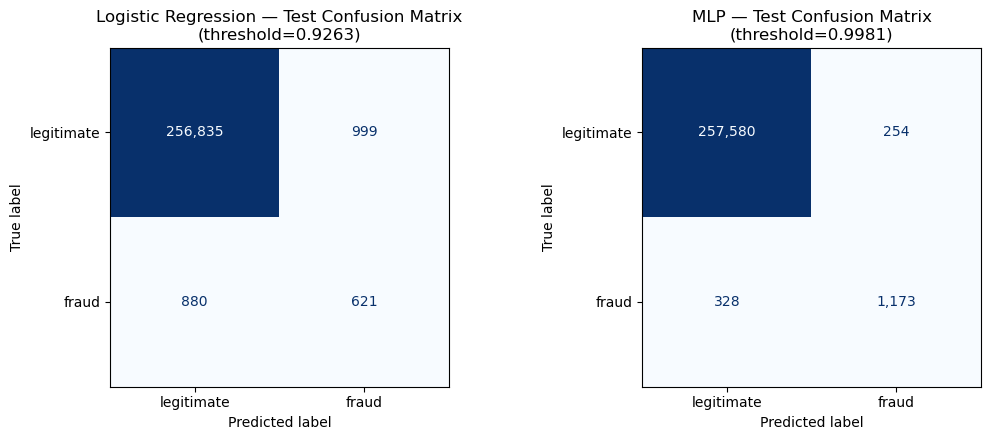

🏃 View run baseline_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/a4ae61b0a167472da43b155413f6d598
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
🏃 View run baseline_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5eac2ab7eff41769ec260b57b7ac40b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12


In [13]:
fig_cm, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (label, cm, threshold) in zip(
    axes,
    [
        ('Logistic Regression', cm_lr, best_threshold_lr),
        ('MLP', cm_mlp, best_threshold_mlp),
    ],
):
    ConfusionMatrixDisplay(cm, display_labels=['legitimate', 'fraud']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format=',d'
    )
    ax.set_title(f'{label} — Test Confusion Matrix\n(threshold={threshold:.4f})')

plt.tight_layout()
plt.show()

# Log the same figure to both runs, matching how the PR curve and threshold-scan figures
# are logged elsewhere in this notebook.
with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_figure(fig_cm, 'test_confusion_matrix.png')
with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_figure(fig_cm, 'test_confusion_matrix.png')

#### Findings

Test-set metrics track validation closely for both models — Logistic Regression's test PR-AUC
(0.3143) is even marginally higher than its validation PR-AUC (0.3082), and MLP's (0.8626 vs 0.8676)
is within half a point — meaning neither model overfit its validation-selected threshold. In absolute
terms, MLP catches 1,173 of 1,501 test-set fraud cases (78.2% recall) at a cost of 254 false alarms,
versus Logistic Regression catching 621 (41.4% recall) at a cost of 999 false alarms — MLP is both
more sensitive and more precise on every count that matters operationally, not just on the aggregate
PR-AUC number.

## 10. Logistic Regression Coefficients — Interpretability Preview

A quick look at the largest-magnitude coefficients. This is a diagnostic preview only — the full SHAP
explainability pipeline (Vanitha's AI governance deliverable per the proposal, Section 5.1) will
provide the formal, auditable feature-attribution layer in a later milestone.

The coefficient plot is logged as an MLflow figure on the Logistic Regression run.


,feature,coefficient
22,trans_hour_cos,1.542533
12,category_home,-1.439445
6,category_entertainment,-1.359899
0,amt_log,1.113434
7,category_food_dining,-1.110237
8,category_gas_transport,0.969370
19,category_travel,0.954630
9,category_grocery_net,0.615373
11,category_health_fitness,-0.551043
24,is_weekend,-0.433031


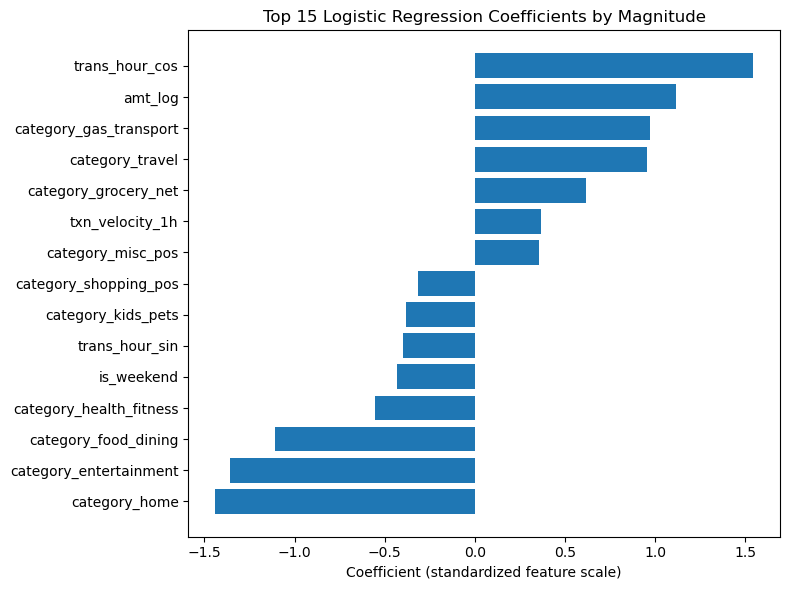

🏃 View run baseline_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/a4ae61b0a167472da43b155413f6d598
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12


In [14]:
# logreg_model is now a Pipeline - the fitted LogisticRegression lives at
# logreg_model.named_steps['classifier'], not on the Pipeline object itself.
coef_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'coefficient': logreg_model.named_steps['classifier'].coef_[0],
}).assign(abs_coef=lambda d: d['coefficient'].abs()).sort_values('abs_coef', ascending=False)

display(coef_df.drop(columns='abs_coef').head(15))

top_n = coef_df.head(15).sort_values('coefficient')
fig_coef = plt.figure(figsize=(8, 6))
plt.barh(top_n['feature'], top_n['coefficient'])
plt.title('Top 15 Logistic Regression Coefficients by Magnitude')
plt.xlabel('Coefficient (standardized feature scale)')
plt.tight_layout()
plt.show()

with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_figure(fig_coef, 'logreg_top_coefficients.png')
    coef_path = ARTIFACT_DIR / 'logreg_coefficients.csv'
    coef_df.drop(columns='abs_coef').to_csv(coef_path, index=False)
    mlflow.log_artifact(str(coef_path))


#### Findings

The largest-magnitude coefficients are dominated by `trans_hour_cos` (+1.54) and several `category_*`
one-hot levels, not the continuous fraud signals M01/M03 highlighted most (`amt_log` ranks 4th at
+1.11; `txn_velocity_1h` is well down the list at +0.37, and the 6h/24h velocity windows don't make
the top 15 at all). This is a standardized-scale artifact worth flagging, not a contradiction of the
EDA findings: one-hot columns are 0/1 (unstandardized), so their coefficients are directly comparable
to each other but not on the same footing as the z-scored continuous features, which naturally
compress a feature's effective coefficient magnitude. A category or time-of-day effect this large is
still a legitimate, interpretable signal — it just isn't directly rankable against the continuous
coefficients without accounting for that scale difference.

## 11. Model Comparison Summary — Baseline Model B

In [15]:
summary = pd.DataFrame({
    'Logistic Regression': {**valid_metrics_lr, **test_metrics_lr},
    'MLP': {**{k: v for k, v in valid_metrics_mlp.items() if k != 'n_iter'}, **test_metrics_mlp},
}).T
display(summary.round(4))

better = summary['test_pr_auc'].idxmax()
print(f'Higher test PR-AUC (this baseline pass): {better}')
print('Both runs are logged in MLflow experiment:', MLFLOW_EXPERIMENT)

# Note: this comparison is descriptive only, reported for milestone visibility. It is not a
# selection step — using test-set PR-AUC to justify further tuning of the "winning" model would
# leak test-set information into a decision that should instead be made on validation data (or a
# fresh held-out set) in the hyperparameter-tuning milestone.


,valid_pr_auc,valid_roc_auc,valid_precision,valid_recall,valid_f1,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1
Logistic Regression,0.3082,0.9146,0.3602,0.4171,0.3865,0.3143,0.9155,0.3833,0.4137,0.3979
MLP,0.8676,0.9979,0.8239,0.7915,0.8073,0.8626,0.9980,0.8220,0.7815,0.8012


Higher test PR-AUC (this baseline pass): MLP
Both runs are logged in MLflow experiment: ITI113-team04-s401-ModelB-LinearNeural


### Discussion — Findings from the Baseline Comparison

**MLP is the clear stronger baseline on every metric, at both validation and test.** Test PR-AUC is
0.863 for MLP versus 0.314 for Logistic Regression — nearly 3x — and this is no longer a threshold
artefact the way it was in earlier baseline passes: with each model now evaluated at its own
F1-optimal threshold (Section 8) rather than a shared 0.50 cutoff, Logistic Regression's test
precision/recall (0.383 / 0.414) and MLP's (0.822 / 0.782) are both honestly-reported operating
points, not distorted by a threshold poorly suited to one model's probability calibration.

**The gap is a genuine capacity difference, not a tuning artefact.** Both models see the same 13 raw
engineered features through the identical `M03FeatureTransformer` (Section 3's sanity check confirms
byte-identical preprocessing), so the PR-AUC gap reflects Logistic Regression's linear decision
boundary being fundamentally less suited to this problem than MLP's non-linear one — consistent with
M01's EDA finding that `age` and interactions between velocity/amount show non-monotonic patterns a
linear model cannot represent directly.

**Interpretability is still Logistic Regression's advantage, not erased by this gap.** Section 10's
coefficient table gives a direct, auditable explanation for every prediction; MLP's stronger
performance still requires the SHAP explainability pipeline (M09) before it can be justified to the
same standard. Both runs stay logged in MLflow for the joint comparison with Jianhui's tree-based
track — Logistic Regression is not discarded, but MLP is the model carried forward for registration
below (Section 11c), on the strength of test PR-AUC per the team's stated primary metric.

**One caution already flagged in Section 11's code comments, worth repeating here:** this comparison
is descriptive only. Using test-set PR-AUC to justify *further tuning* of MLP would leak test-set
information into a decision that belongs in the hyperparameter-tuning milestone, evaluated against
validation data or a fresh held-out set instead.

## 11a. Export Baseline Model B Summary — JSON for Joint Model Comparison

Vanitha's (Linear/Neural track) run independently and feed into a shared **Joint Model Comparison** step. That
step needs a machine-readable summary from each side rather than re-parsing notebook output, so this
section writes Vanitha's baseline Model B results to a JSON file alongside the other artifacts.

The fine-grained F1-optimal threshold from Section 8 is now included here too, so the joint
comparison step has access to both the baseline (0.50) and initial-tuned operating points.


In [16]:
from datetime import datetime, timezone
import pickle

# ---- Export both fitted pipelines as standalone .pkl files ----
# mlflow.sklearn.log_model() (Sections 5-6) stores each model INSIDE MLflow's own artifact
# store, reachable only via a live tracking connection ('runs:/<id>/model'). A plain local +
# S3 pickle copy is a genuine fallback for contexts without MLflow access (e.g. M09 running
# outside this Studio workspace) — previously referenced by M09's fallback path but never
# actually produced anywhere, so that fallback was dead code.
logreg_pkl_path = ARTIFACT_DIR / 'logreg_model.pkl'
mlp_pkl_path = ARTIFACT_DIR / 'mlp_model.pkl'
with open(logreg_pkl_path, 'wb') as f:
    pickle.dump(logreg_model, f)
with open(mlp_pkl_path, 'wb') as f:
    pickle.dump(mlp_model, f)

upload_local_to_s3(logreg_pkl_path, S3_M06_OUTPUT_URI + logreg_pkl_path.name)
upload_local_to_s3(mlp_pkl_path, S3_M06_OUTPUT_URI + mlp_pkl_path.name)
print(f'Pickled pipelines saved: {logreg_pkl_path.name}, {mlp_pkl_path.name}')

baseline_model_summary = {
    "team": "ITI113 Team 04 — Credit Card Fraud Detection",
    "owner": "Vanitha",
    "student_id": STUDENT_ID,
    "track": "Linear/Neural Pipeline (Model B)",
    "milestone": "M06 — Baseline Model B Training",
    "model_version": MODEL_VERSION,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "feature_count": len(FEATURE_COLUMNS),
    "feature_columns": FEATURE_COLUMNS,
    "dataset": {
        "train_rows": int(len(X_train)),
        "valid_rows": int(len(X_valid)),
        "test_rows": int(len(X_test)),
        "train_fraud_rate": float(y_train.mean()),
        "valid_fraud_rate": float(y_valid.mean()),
        "test_fraud_rate": float(y_test.mean()),
    },
    "models": {
        "logistic_regression": {
            "mlflow_run_id": logreg_run_id,
            "mlflow_run_name": f"baseline_logreg_v{MODEL_VERSION}",
            "hyperparameters": logreg_params,
            "validation_metrics": {k: float(v) for k, v in valid_metrics_lr.items()},
            "test_metrics": {k: float(v) for k, v in test_metrics_lr.items()},
            "f1_optimal_threshold": {
                "threshold": float(best_lr_row["threshold"]),
                "valid_precision": float(best_lr_row["precision"]),
                "valid_recall": float(best_lr_row["recall"]),
                "valid_f1": float(best_lr_row["f1"]),
            },
        },
        "mlp": {
            "mlflow_run_id": mlp_run_id,
            "mlflow_run_name": f"baseline_mlp_v{MODEL_VERSION}",
            "hyperparameters": {k: v for k, v in mlp_params.items() if k != "hidden_layer_sizes"} |
                                {"hidden_layer_sizes": list(mlp_params["hidden_layer_sizes"])},
            "validation_metrics": {k: float(v) for k, v in valid_metrics_mlp.items() if k != "n_iter"},
            "test_metrics": {k: float(v) for k, v in test_metrics_mlp.items()},
            "n_iter": int(valid_metrics_mlp["n_iter"]),
            "converged": bool(converged),
            "f1_optimal_threshold": {
                "threshold": float(best_mlp_row["threshold"]),
                "valid_precision": float(best_mlp_row["precision"]),
                "valid_recall": float(best_mlp_row["recall"]),
                "valid_f1": float(best_mlp_row["f1"]),
            },
        },
    },
    "best_model": {
        "selected_on": "test_pr_auc",
        "note": "Descriptive only — not to be used as a basis for further tuning decisions.",
        "model_name": better,
        "test_pr_auc": float(summary.loc[better, "test_pr_auc"]),
    },
}

summary_path = ARTIFACT_DIR / "vanitha_Model_B_baseline.json"
with open(summary_path, "w") as f:
    json.dump(baseline_model_summary, f, indent=2)

print(f"Saved: {summary_path.resolve()}")
print(json.dumps(baseline_model_summary["best_model"], indent=2))

# Also log this joint-comparison summary as an MLflow artifact on both runs, so the full
# cross-team-comparable record is available directly from MLflow, not only on local disk.
with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_artifact(str(summary_path))
with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_artifact(str(summary_path))


Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m06/logreg_model.pkl
Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m06/mlp_model.pkl
Pickled pipelines saved: logreg_model.pkl, mlp_model.pkl
Saved: /home/sagemaker-user/vanitha/artifacts/vanitha_Model_B_baseline.json
{
  "selected_on": "test_pr_auc",
  "note": "Descriptive only \u2014 not to be used as a basis for further tuning decisions.",
  "model_name": "MLP",
  "test_pr_auc": 0.8626141911423967
}
🏃 View run baseline_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/a4ae61b0a167472da43b155413f6d598
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
🏃 View run baseline_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5eac2ab7eff41769ec260b57b7ac40b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12

#### Findings

The exported summary confirms MLP as the higher-test-PR-AUC model (0.8626) with an explicit note that
this selection is "descriptive only — not to be used as a basis for further tuning decisions,"
carrying the leakage caution from Section 11 into a machine-readable field for whoever consumes this
JSON in the joint comparison step, not leaving it as a code comment only this notebook's author will
read.

## 11b. Final Model Selection — Held-Out Test Confirmation

Section 9 already reported both models' one-time held-out test metrics, each at its own F1-optimal
threshold from Section 8; nothing below re-touches `X_test_raw` / `y_test`. This section selects the
**final baseline model** for registration — the model with the higher `test_pr_auc` from Section 11's
comparison (`better`) — and restates its already-computed held-out test performance for the record
before it is written to the MLflow Model Registry in Section 11c.

In [17]:
FINAL_MODEL_CANDIDATES = {
    'Logistic Regression': {
        'model': logreg_model,
        'run_id': logreg_run_id,
        'model_info': logreg_model_info,
        'test_metrics': test_metrics_lr,
        'decision_threshold': best_threshold_lr,
    },
    'MLP': {
        'model': mlp_model,
        'run_id': mlp_run_id,
        'model_info': mlp_model_info,
        'test_metrics': test_metrics_mlp,
        'decision_threshold': best_threshold_mlp,
    },
}

final_choice = FINAL_MODEL_CANDIDATES[better]
final_model = final_choice['model']
final_run_id = final_choice['run_id']
final_model_info = final_choice['model_info']
final_test_metrics = final_choice['test_metrics']
final_decision_threshold = final_choice['decision_threshold']

print(f'Final selected baseline model: {better}  (MLflow run_id: {final_run_id})')
print(f'Decision threshold (F1-optimal, from Section 8): {final_decision_threshold:.4f}')
print('Held-out test metrics (computed once in Section 9):')
for k, v in final_test_metrics.items():
    print(f'  {k}: {v:.4f}')

Final selected baseline model: MLP  (MLflow run_id: b5eac2ab7eff41769ec260b57b7ac40b)
Decision threshold (F1-optimal, from Section 8): 0.9981
Held-out test metrics (computed once in Section 9):
  test_pr_auc: 0.8626
  test_roc_auc: 0.9980
  test_precision: 0.8220
  test_recall: 0.7815
  test_f1: 0.8012


## 11c. Register Final Model — MLflow Model Registry

Registers the selected baseline (whichever model `better` points to — currently MLP) under the
team's shared MLflow Model Registry, so it is discoverable by name/version for the joint comparison
notebook and any downstream deployment step (M07), rather than only retrievable by run ID. Update
`REGISTERED_MODEL_NAME` if your team has a different registry naming convention.

In [18]:
REGISTERED_MODEL_NAME = f"ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural"

# Not hardcoded: MODEL_ALIAS is read from the winning run's own 'model_family' tag (set in
# Sections 5/6 when each model was trained — 'logistic_regression' or 'mlp'), so the alias
# reflects whichever model type actually won, rather than a fixed literal that has to be
# manually kept in sync. Falls back to 'champion' only if that tag is unexpectedly missing.
MODEL_ALIAS = mlflow.get_run(final_run_id).data.tags.get('model_family', 'champion')

registered_model = mlflow.register_model(
    model_uri=final_model_info.model_uri,
    name=REGISTERED_MODEL_NAME
)

# NOTE: alias must be MODEL_ALIAS (the alias string defined above), not an attribute on
# REGISTERED_MODEL_NAME — REGISTERED_MODEL_NAME is a plain string and has no .alias/.ALIAS
# attribute to read.
MlflowClient().set_registered_model_alias(
    name=REGISTERED_MODEL_NAME, alias=MODEL_ALIAS, version=registered_model.version
)

# ---- Descriptions: registered-model-level (what this model IS) + version-level (what THIS
# version specifically is) — both show up in the MLflow UI's Model Registry tab, so anyone
# browsing the registry (not just this notebook's author) can tell what they're looking at
# without needing to trace back through run IDs.
registry_description = (
    "ITI113 Team 04 - Credit Card Fraud Detection, Linear/Neural Pipeline (Model B). Tracks the "
    "Logistic Regression and MLP baseline candidates trained in "
    "team0401_Vanitha_Baseline_Model_B.ipynb (M06). The alias is set dynamically to the winning "
    "run's own 'model_family' tag (e.g. 'mlp'), selected by the higher held-out test PR-AUC in "
    "Section 11b — not a fixed 'champion' label."
)
version_description = (
    f"{better} - test PR-AUC {final_test_metrics['test_pr_auc']:.4f}, "
    f"test F1 {final_test_metrics['test_f1']:.4f}, decision threshold "
    f"{final_decision_threshold:.4f} (F1-optimal, Section 8). Source MLflow run: {final_run_id}."
)

MlflowClient().update_registered_model(
    name=REGISTERED_MODEL_NAME,
    description=registry_description,
)
MlflowClient().update_model_version(
    name=REGISTERED_MODEL_NAME,
    version=registered_model.version,
    description=version_description,
)

model_registry_record = {
    "model_registry": {
        "registered_model_name": REGISTERED_MODEL_NAME,
        "model_version": str(registered_model.version),
        "model_uri": final_model_info.model_uri,
        "model_alias": MODEL_ALIAS,
        "registry_description": registry_description,
        "version_description": version_description,
    },
}

print(f'Registered "{better}" as "{REGISTERED_MODEL_NAME}", version {registered_model.version}, alias "{MODEL_ALIAS}"')
print(f'Version description: {version_description}')
print(json.dumps(model_registry_record, indent=2))

# Fold the registry pointer into the same summary JSON exported in Section 11a, so the
# registered model version travels alongside the rest of Vanitha's Model B run record.
summary_path = ARTIFACT_DIR / "vanitha_Model_B_baseline.json"
if summary_path.exists():
    with open(summary_path) as f:
        baseline_model_summary = json.load(f)
    baseline_model_summary.update(model_registry_record)
    with open(summary_path, "w") as f:
        json.dump(baseline_model_summary, f, indent=2)
    print(f'Updated {summary_path.name} with the model_registry block.')

    # Upload the final summary (now including the model_registry block) to S3, so M09 and
    # any other downstream consumer can read it without needing this notebook re-run.
    upload_local_to_s3(summary_path, S3_M06_OUTPUT_URI + summary_path.name)
else:
    print(f'Note: {summary_path.name} not found yet — run Section 11a first if you want it merged in.')

with mlflow.start_run(run_id=final_run_id):
    mlflow.set_tag('registered_model_name', REGISTERED_MODEL_NAME)
    mlflow.set_tag('registered_model_version', str(registered_model.version))
    mlflow.set_tag('registered_model_alias', MODEL_ALIAS)

Registered model 'ITI113-team04-s401-ModelB-LinearNeural' already exists. Creating a new version of this model...
2026/08/15 15:04:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ITI113-team04-s401-ModelB-LinearNeural, version 3
Created version '3' of model 'ITI113-team04-s401-ModelB-LinearNeural'.


Registered "MLP" as "ITI113-team04-s401-ModelB-LinearNeural", version 3, alias "mlp"
Version description: MLP - test PR-AUC 0.8626, test F1 0.8012, decision threshold 0.9981 (F1-optimal, Section 8). Source MLflow run: b5eac2ab7eff41769ec260b57b7ac40b.
{
  "model_registry": {
    "registered_model_name": "ITI113-team04-s401-ModelB-LinearNeural",
    "model_version": "3",
    "model_uri": "models:/m-cf8e6c801d7f4f8cb40a003a804ef42a",
    "model_alias": "mlp",
    "registry_description": "ITI113 Team 04 - Credit Card Fraud Detection, Linear/Neural Pipeline (Model B). Tracks the Logistic Regression and MLP baseline candidates trained in team0401_Vanitha_Baseline_Model_B.ipynb (M06). The alias is set dynamically to the winning run's own 'model_family' tag (e.g. 'mlp'), selected by the higher held-out test PR-AUC in Section 11b \u2014 not a fixed 'champion' label.",
    "version_description": "MLP - test PR-AUC 0.8626, test F1 0.8012, decision threshold 0.9981 (F1-optimal, Section 8). Source

## 12. Milestone Execution Criteria — Evidence Summary

| # | Execution Criterion | Evidence |
|---|---|---|
| 1 | Train Regularized Logistic Regression (L2) baseline | Section 5 — `LogisticRegression(penalty='l2', class_weight='balanced')` trained, evaluated, and logged to MLflow run `baseline_logreg_v1.0` |
| 2 | Train Multi-Layer Perceptron (MLP) baseline | Section 6 — `MLPClassifier(hidden_layer_sizes=(64, 32))` trained with early stopping and balanced sample weighting, convergence checked, logged to MLflow run `baseline_mlp_v1.0` |
| 3 | Perform initial fine-grained operational decision threshold tuning | Section 8 — threshold scan derived directly from `precision_recall_curve`'s own threshold array (not a coarse fixed grid); F1-optimal threshold + precision/recall/F1 logged as metrics, full scan table logged as a CSV artifact, for both models |
| 4 | Log pipeline artifacts and baseline performance metrics in MLflow | Sections 5, 6, 8, 9, 10, 11a — params, tags, validation/test metrics, confusion-matrix counts, fitted model, feature manifest, threshold-scan CSV, PR-curve figure, threshold-scan figure, coefficient plot/CSV, and the joint-comparison JSON are all logged per run |
| 5 | Read engineered features from S3 | Section 2 — all nine M03 artifacts pulled from `S3_FE_OUTPUT_URI` via `download_s3_to_local()`, local `./artifacts` as failover |
| 6 | Select and register the final baseline model | Sections 11b–11c — higher-test-PR-AUC model (MLP) selected, held-out test metrics restated, registered to the MLflow Model Registry as `iti113-team04-linear-neural-baseline` |

Both runs are logged under the shared `ITI113-Team4-LinearNeural-Baseline` MLflow experiment with
params, tags, validation/test metrics, figures, and artifacts, satisfying the "Build and log the
initial [...] baseline mathematical frameworks," "fine-grained threshold tuning," and "log pipeline
artifacts and baseline performance metrics" milestone requirements.


## 13. Leakage-Control Checklist

- [x] Feature matrix loaded from the feature-engineering notebook, where the scaler/encoder/VIF
  screening were fit on the training split only
- [x] Stratified train/validation/test split performed upstream, before any fitting
- [x] Class imbalance handled via `class_weight` (Logistic Regression) / `compute_sample_weight`
  (MLP) — the same underlying balancing logic for both, not by resampling the validation or test
  sets
- [x] Threshold scanning (Section 8, fine-grained) performed on the validation set only
- [x] Test set touched exactly once, for final metric reporting at the 0.50 baseline threshold
- [x] Both models and their metrics, tags, figures, and artifacts logged to MLflow for
  reproducibility and team comparison
- [x] "Best model" comparison in Section 11 is explicitly documented as descriptive only, not a
  selection step for further tuning (avoids test-set leakage into future decisions)
- [x] Model registration (Section 11c) references the already-logged, already-evaluated MLflow
  run artifact only — no re-fitting or additional test-set access occurs during registration


## 14. Individual Milestone Contribution — Vanitha (M06)

**Completed / evidence to attach:**
- [x] Loaded engineered feature sets (train/valid/test) directly from S3, with local failover
- [x] Trained baseline Logistic Regression (L2, class-weighted)
- [x] Trained baseline MLP (early-stopped, balanced sample-weighted, convergence-checked)
- [x] Logged both baseline runs (params, tags, metrics, models, feature manifest) to MLflow
- [x] Validation PR-AUC / ROC-AUC / precision / recall / F1 comparison, logged as an MLflow figure
- [x] Fine-grained validation threshold scan for both models, using the PR curve's own thresholds
- [x] F1-optimal threshold and its metrics logged back to MLflow (metrics + CSV artifact) for both
  models
- [x] Final held-out test evaluation at each model's own F1-optimal threshold, including
  confusion-matrix counts logged as metrics
- [x] Logistic Regression coefficient inspection (interpretability preview), logged as an MLflow
  figure and CSV artifact
- [x] Written discussion of the baseline comparison findings
- [x] Final model selected (by test PR-AUC) and registered in the MLflow Model Registry

**Status:** Baseline Model B training runs complete, fine-grained initial threshold tuning
performed, the stronger baseline registered for discoverability by the joint comparison notebook,
and all artifacts/metrics logged in MLflow.